# Multi-head attention

Several heads let the model compute different query-key relationships in parallel. Each head works at a smaller channel width; their outputs are concatenated and projected back to the model width.

In [1]:
import math
import random
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
from torch.nn import functional as F

SEED = 7
random.seed(SEED)
torch.manual_seed(SEED)
sns.set_theme(style="whitegrid", context="notebook")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

Matplotlib is building the font cache; this may take a moment.


device: cpu


In [2]:
class MultiHeadAttention(nn.Module):
    def __init__(self, channels, heads, max_time):
        super().__init__()
        if channels % heads:
            raise ValueError("channels must be divisible by heads")
        self.heads, self.head_size = heads, channels // heads
        self.query = nn.Linear(channels, channels, bias=False)
        self.key = nn.Linear(channels, channels, bias=False)
        self.value = nn.Linear(channels, channels, bias=False)
        self.output = nn.Linear(channels, channels)
        self.register_buffer("mask", torch.tril(torch.ones(max_time, max_time, dtype=torch.bool)))

    def forward(self, x):
        batch, time, channels = x.shape
        def split_heads(tensor):
            tensor = tensor.view(batch, time, self.heads, self.head_size)
            return tensor.transpose(1, 2)
        q, k, v = map(split_heads, (self.query(x), self.key(x), self.value(x)))
        scores = q @ k.transpose(-2,-1) / math.sqrt(self.head_size)
        scores = scores.masked_fill(~self.mask[:time,:time], float("-inf"))
        weights = torch.softmax(scores, dim=-1)
        head_outputs = weights @ v
        combined = head_outputs.transpose(1,2).contiguous().view(batch,time,channels)
        return self.output(combined), weights

module = MultiHeadAttention(channels=16, heads=4, max_time=10).to(DEVICE)
x = torch.randn(2,10,16,device=DEVICE)
y, weights = module(x)
print("x:",tuple(x.shape),"head weights:",tuple(weights.shape),"y:",tuple(y.shape))

x: (2, 10, 16) head weights: (2, 4, 10, 10) y: (2, 10, 16)


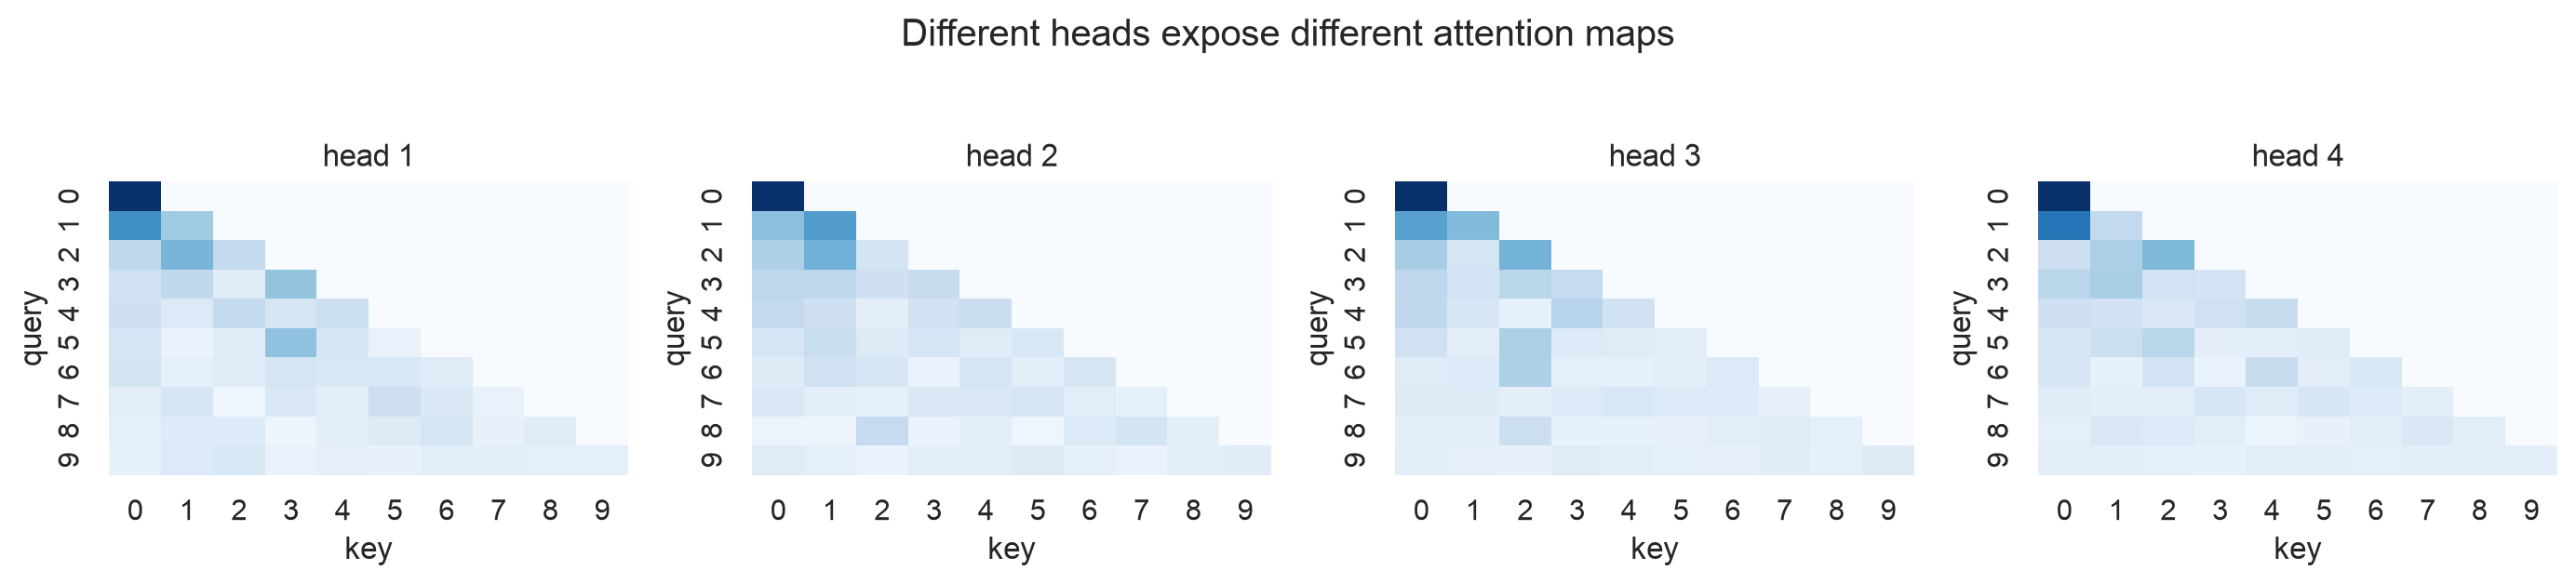

In [3]:
fig, axes = plt.subplots(1,4,figsize=(14,3))
for head, ax in enumerate(axes):
    sns.heatmap(weights[0,head].detach().cpu(), vmin=0, vmax=1, cmap="Blues", cbar=False, ax=ax)
    ax.set(title=f"head {head+1}", xlabel="key", ylabel="query")
plt.suptitle("Different heads expose different attention maps", y=1.04)
plt.tight_layout(); plt.show()

## Why split into heads?

With one head, every relationship must share one query space, one key space, and one value mixture. Multi-head attention divides the channel width into smaller subspaces. One head may emphasize local continuation, another may emphasize a repeated symbol, and another may remain nearly uniform. The model learns these roles; they are not assigned by hand.

## Shape bookkeeping

The input width is `C`. With `H` heads, each head has width `C/H`. The projections produce `(batch, time, H, C/H)`, which is transposed to `(batch, H, time, C/H)` for parallel score matrices. After aggregation, the heads are transposed and concatenated back to `(batch, time, C)` before the output projection.

The maps are useful diagnostics, but they are not a complete explanation of what a head represents. The head outputs are mixed by a learned projection, and the model can distribute one computation across several heads. The next notebook adds the feed-forward path, residual stream, and normalization to form a Transformer block.